=============================================================================
MISSOURI VOTER RESOURCE ALLOCATION PROJECT
=============================================================================
Course: CAPS 5576 - Analytics Applications
Team: Group 1
Project: Prescriptive and Predictive Voter Resource Allocation
Focus: Missouri Presidential Elections (2016, 2020, 2024)
=============================================================================

COLLABORATION NOTE:
-------------------
This notebook was initially built in an individual environment (SNOWBEARAIR_DB).
Once it was validated, it was ported here to a shared team GitHub account
where all 4 team members can collaborate.

=============================================================================

FILES REQUIRED (upload as notebook assets before execution):
------------------------------------------------------------

ELECTION DATA (3 files):
- MO 2016 Election Results.csv
- MO 2020 Election Results.csv
- MO 2024 Election Results.csv

CENSUS DATA - 2016 (5 files):
- MO 2016 Census Income.csv
- MO 2016 Census Education.csv
- MO 2016 Census Race.csv
- MO 2016 Census Commute.csv
- MO 2016 Census Sex by Age.csv

CENSUS DATA - 2020 (5 files):
- MO 2020 Census Income.csv
- MO 2020 Census Education.csv
- MO 2020 Census Race.csv
- MO 2020 Census Commute.csv
- MO 2020 Census Sex by Age.csv

CENSUS DATA - 2024 (5 files):
- MO 2024 Census Income.csv
- MO 2024 Census Education.csv
- MO 2024 Census Race.csv
- MO 2024 Census Commute.csv
- MO 2024 Census Sex by Age.csv

POLLING LOCATION DATA (1 file):
- MO 2020 Polling Locations.csv

SHAPEFILE DATA (5 files):
- MO 2020 Precincts.shp
- MO 2020 Precincts.dbf
- MO 2020 Precincts.shx
- MO 2020 Precincts.prj
- MO 2020 Precincts.cpg

TOTAL: 24 files

=============================================================================

NOTEBOOK STRUCTURE:
-------------------
SECTION 1: Documentation & Setup

SECTION 2: Data Ingestion

SECTION 3: Data Cleaning - Election Data

SECTION 4: Data Cleaning - Census Data

SECTION 5: Data Cleaning - Polling & Shapefile

SECTION 6: Data Integration

SECTION 7: Pandas Aggregations & Merges

SECTION 8: Data Quality Validation

SECTION 9: Exploratory Data Analysis

SECTION 10: Geospatial Analysis - inserted for David's geospatial idea

SECTION 11: Summary & Next Steps

=============================================================================

# Missouri Voter Resource Allocation Project

## Project Goal
Analyze historical presidential election results alongside demographic and geographic data to evaluate how polling resources could potentially be allocated more effectively across Missouri precincts.

## Analysis Focus
The analysis focuses on **three presidential election cycles**: 2016, 2020, and 2024.

Presidential election years were chosen because they produce the **highest voter turnout** and the **most consistent statewide participation**. Focusing on presidential election cycles provides a clearer signal for modeling voter demand and analyzing polling resource allocation across precincts.

## Data Architecture
The project integrates several categories of data:
- **Presidential election results** (precinct-level) - 2016, 2020, 2024
- **Census demographic data** (county-level) - ACS 5-Year Estimates aligned to each election
- **Polling location data** - Physical polling places by precinct
- **Precinct boundaries** (optional) - Geographic shapefiles for spatial analysis

## Programming Paradigms
- **Imperative (Python):** Data loading, cleaning, transformations
- **Declarative (SQL):** Joins, aggregations, analytical queries

## Coding Standards
- snake_case naming with meaningful variable names
- One output per cell
- Explanations in Markdown cells (not inline comments)
- Pandas method chaining
- List comprehensions over loops

# Data Sources

## Election Results Data

**Source:** OpenElections Project (GitHub)  
https://github.com/openelections/openelections-data-mo

**Files:**
- MO 2016 Election Results.csv (128,859 rows)
- MO 2020 Election Results.csv (132,123 rows)
- MO 2024 Election Results.csv (190,270 rows)

These datasets contain precinct-level vote totals for each candidate and office. Each row represents the vote total for one candidate within a specific precinct.

**Schema Note:** The 2020 and 2024 files include a `precinct_code` column not present in 2016. This column is dropped during preprocessing to maintain a consistent schema.

## Census Demographic Data

**Source:** U.S. Census Bureau – American Community Survey (ACS) 5-Year Estimates  
https://data.census.gov

Demographic data was aligned with each presidential election year:
- **2016 Election** → ACS 2012-2016
- **2020 Election** → ACS 2016-2020
- **2024 Election** → ACS 2020-2024

**Tables Used (5 per year = 15 files total):**
- B01001 – Sex by Age
- B02001 – Race
- B08301 – Commuting / Transportation to Work
- B15003 – Educational Attainment
- B19013 – Median Household Income

All ACS datasets are at the **county level** for Missouri.

## Polling Location Data

**Source:** MIT Election Data and Science Lab  
https://electionlab.mit.edu/data

**File:** MO 2020 Polling Locations.csv (14,354 rows)

Contains polling locations associated with Missouri precincts. Although the data represents the 2020 election cycle, polling locations generally change slowly, making the dataset suitable for analysis across nearby election years.

## Precinct Geographic Files

**Source:** U.S. Census TIGER/Line Shapefiles  

**Files:** MO 2020 Precincts (.shp, .dbf, .shx, .prj, .cpg)

These files represent Missouri Voting Tabulation District (precinct) boundaries. They may be used for:
- Mapping turnout geographically
- Spatial analysis of polling locations
- Calculating distances between voters and polling places

# Data Preprocessing Requirements

## Election Data Preprocessing

1. **Add election year column** - Enables combining datasets from different cycles
2. **Remove precinct_code column** - Not present in 2016, dropped from 2020/2024
3. **Normalize precinct names** - Uppercase, remove special characters, trim whitespace
4. **Normalize county names** - Uppercase and trim whitespace
5. **Filter to Presidential results only** - Focus analysis on highest-turnout races

## Census Data Preprocessing

1. **Remove header artifact row** - ACS exports include a metadata row where GEO_ID = "Geography"
2. **Remove blank export columns** - Drop any "Unnamed" columns from export artifacts
3. **Extract county name** - Parse from NAME field, removing " County, Missouri" suffix
4. **Add census year column** - Track which ACS vintage the data comes from
5. **Convert to numeric types** - Ensure proper data types for analysis

## Data Preprocessing

### Election Data Preprocessing
Before combining election datasets, several preprocessing steps are performed.

Add election year column:

```python
df2016["year"] = 2016
df2020["year"] = 2020
df2024["year"] = 2024
```

Remove precinct_code where present:

```python
df = df.drop(columns=["precinct_code"], errors="ignore")
```

Normalize precinct names:

```python
df["precinct_clean"] = (
    df["precinct"]
    .astype(str)
    .str.upper()
    .str.replace("#","")
    .str.replace("  "," ")
    .str.strip()
)
```

### Census Data Preprocessing
Census datasets exported from data.census.gov contain some artifacts that should be cleaned.

Remove header artifact row:

```python
df = df[df["GEO_ID"] != "Geography"]
```

Remove blank export columns:

```python
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
```

Extract county name:

```python
df["county_clean"] = (
    df["NAME"]
    .str.replace(", Missouri", "", regex=False)
    .str.replace(" County", "", regex=False)
    .str.upper()
)
```

**Important – St. Louis County vs. St. Louis City:**
Missouri has both "St. Louis County" (FIPS 29189) and "St. Louis city" (FIPS 29510), which is an independent city that is not part of any county. The cleaning process preserves this distinction by only removing " County" from county names, not " city". This results in:

- St. Louis County → "ST. LOUIS"
- St. Louis city → "ST. LOUIS CITY"

**Warning:** If both entities are cleaned to the same name, JOINs between election and census data will produce duplicate rows (a cartesian product), leading to inflated row counts in analytical tables.

Add census year column:

```python
df["census_year"] = 2016  # or 2020 or 2024
```

## Snowflake Implementation Notes

### Column Naming and Case Sensitivity

Snowflake handles column names differently depending on how tables are created:

**Staging Tables (created via Python/Snowpark):**
- Column names are lowercase (e.g., `year`, `county_clean`, `votes`)
- Must use double quotes in SQL to reference them: `"year"`, `"county_clean"`

**Analytical Tables (created via SQL):**
- Use uppercase aliases when creating: `SELECT "year" AS YEAR, "county_clean" AS COUNTY`
- This allows unquoted references in downstream SQL: `WHERE YEAR = 2020`

### Snowflake Table Structure

**Staging Tables (loaded via Python):**

STG_ELECTION_RESULTS – Combined presidential election results (all years)

STG_CENSUS_INCOME – Median household income by county

STG_CENSUS_EDUCATION – Educational attainment by county

STG_CENSUS_RACE – Race demographics by county

STG_CENSUS_COMMUTE – Commuting patterns by county

STG_CENSUS_SEX_AGE – Sex and age demographics by county

STG_POLLING_LOCATIONS – Polling place locations

**Analytical Tables (created via SQL):**

PRECINCT_TURNOUT – Aggregated votes by precinct and year

COUNTY_TURNOUT – Aggregated votes by county and year

COUNTY_TURNOUT_TREND – Pivoted view with all years side by side

COUNTY_CENSUS – Combined census demographics with all years

COUNTY_ANALYSIS – Joined turnout and census data for analysis

COUNTY_POLLING_SUMMARY – Polling locations aggregated by county

COUNTY_VIZ_EXPORT – Final export table for visualization tools

### Expected Row Counts

| Table | Expected Rows | Notes |
|-------|---------------|-------|
| STG_ELECTION_RESULTS | ~70,000 | Presidential votes only |
| STG_CENSUS_* | 345 each | 115 counties × 3 years |
| STG_POLLING_LOCATIONS | ~14,000 | 2020 polling places |
| PRECINCT_TURNOUT | ~10,000 | Precincts × 3 years |
| COUNTY_TURNOUT | 348 | 116 counties × 3 years |
| COUNTY_TURNOUT_TREND | 117 | One row per county |
| COUNTY_CENSUS | 345 | 115 counties × 3 years |
| COUNTY_ANALYSIS | 117 | One row per county |
| COUNTY_POLLING_SUMMARY | 116 | One row per county |

Note: Missouri has 114 counties plus the independent city of St. Louis, for a total of 115 county-level entities. Some election data may show 116 counties due to Kansas City reporting.

## Verified Results

Statewide presidential election totals match official Missouri results:

| Year | Total Votes | Republican % | Democrat % |
|------|-------------|--------------|------------|
| 2016 | 2,808,298 | 56.78% | 38.14% |
| 2020 | 2,963,270 | 57.17% | 41.03% |
| 2024 | 2,995,327 | 58.49% | 40.08% |


In [31]:
# =============================================================================
# CONFIGURATION AND SETUP
# =============================================================================
# FIRST TIME SETUP: If packages are missing, run this once:
# !pip install geopandas pyarrow
#
# Update DATA_PATH to match your local folder structure.
# For GitHub: Use relative path 'Data/' if your folder structure is:
#   Final Project/
#   ├── Data/
#   │   └── ... (all CSV and shapefile files)
#   └── MO_Voter_Project.ipynb

# ------------- UPDATE THIS PATH IF NEEDED -------------
DATA_PATH = '../Data/'
# ------------------------------------------------------

# =============================================================================
# LIBRARY IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

print('=' * 70)
print('LIBRARIES LOADED')
print('=' * 70)
print(f'pandas:     {pd.__version__}')
print(f'numpy:      {np.__version__}')
print(f'geopandas:  {gpd.__version__}')
print(f'DATA_PATH:  {DATA_PATH}')
print('=' * 70)


LIBRARIES LOADED
pandas:     2.2.3
numpy:      1.26.4
geopandas:  1.1.3
DATA_PATH:  ../Data/


---
# SECTION 2: Data Ingestion
---

Load all raw data files into pandas DataFrames.


In [32]:
# Load Election Results (All Three Years)

raw_election_2016 = pd.read_csv(DATA_PATH + 'MO 2016 Election Results.csv', keep_default_na=False, na_values=[''])
raw_election_2020 = pd.read_csv(DATA_PATH + 'MO 2020 Election Results.csv', keep_default_na=False, na_values=[''])
raw_election_2024 = pd.read_csv(DATA_PATH + 'MO 2024 Election Results.csv', keep_default_na=False, na_values=[''])

print('=' * 70)
print('ELECTION DATA LOADED')
print('=' * 70)
print(f'2016: {raw_election_2016.shape[0]:,} rows')
print(f'2020: {raw_election_2020.shape[0]:,} rows')
print(f'2024: {raw_election_2024.shape[0]:,} rows')
print('=' * 70)



ELECTION DATA LOADED
2016: 128,859 rows
2020: 132,123 rows
2024: 190,270 rows


/var/folders/59/n7h32tsj5s33rc_rv4x9mh6c0000gn/T/ipykernel_65214/3614553115.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_election_2020 = pd.read_csv(DATA_PATH + 'MO 2020 Election Results.csv', keep_default_na=False, na_values=[''])


In [33]:
# Load Census Data - 2016 (ACS 2012-2016)

raw_census_2016_income = pd.read_csv(DATA_PATH + 'MO 2016 Census Income.csv', keep_default_na=False, na_values=[''])
raw_census_2016_education = pd.read_csv(DATA_PATH + 'MO 2016 Census Education.csv', keep_default_na=False, na_values=[''])
raw_census_2016_race = pd.read_csv(DATA_PATH + 'MO 2016 Census Race.csv', keep_default_na=False, na_values=[''])
raw_census_2016_commute = pd.read_csv(DATA_PATH + 'MO 2016 Census Commute.csv', keep_default_na=False, na_values=[''])
raw_census_2016_sex_age = pd.read_csv(DATA_PATH + 'MO 2016 Census Sex by Age.csv', keep_default_na=False, na_values=[''])

print('CENSUS 2016 DATA LOADED')


CENSUS 2016 DATA LOADED


In [34]:
# Load Census Data - 2020 (ACS 2016-2020)

raw_census_2020_income = pd.read_csv(DATA_PATH + 'MO 2020 Census Income.csv', keep_default_na=False, na_values=[''])
raw_census_2020_education = pd.read_csv(DATA_PATH + 'MO 2020 Census Education.csv', keep_default_na=False, na_values=[''])
raw_census_2020_race = pd.read_csv(DATA_PATH + 'MO 2020 Census Race.csv', keep_default_na=False, na_values=[''])
raw_census_2020_commute = pd.read_csv(DATA_PATH + 'MO 2020 Census Commute.csv', keep_default_na=False, na_values=[''])
raw_census_2020_sex_age = pd.read_csv(DATA_PATH + 'MO 2020 Census Sex by Age.csv', keep_default_na=False, na_values=[''])

print('CENSUS 2020 DATA LOADED')


CENSUS 2020 DATA LOADED


In [35]:
# Load Census Data - 2024 (ACS 2020-2024)

raw_census_2024_income = pd.read_csv(DATA_PATH + 'MO 2024 Census Income.csv', keep_default_na=False, na_values=[''])
raw_census_2024_education = pd.read_csv(DATA_PATH + 'MO 2024 Census Education.csv', keep_default_na=False, na_values=[''])
raw_census_2024_race = pd.read_csv(DATA_PATH + 'MO 2024 Census Race.csv', keep_default_na=False, na_values=[''])
raw_census_2024_commute = pd.read_csv(DATA_PATH + 'MO 2024 Census Commute.csv', keep_default_na=False, na_values=[''])
raw_census_2024_sex_age = pd.read_csv(DATA_PATH + 'MO 2024 Census Sex by Age.csv', keep_default_na=False, na_values=[''])

print('CENSUS 2024 DATA LOADED')


CENSUS 2024 DATA LOADED


In [36]:
# Load Polling Locations Data

raw_polling_locations = pd.read_csv(DATA_PATH + 'MO 2020 Polling Locations.csv', keep_default_na=False, na_values=[''])

print(f'POLLING LOCATIONS LOADED: {raw_polling_locations.shape[0]:,} rows')


POLLING LOCATIONS LOADED: 14,354 rows


In [37]:
# Load Shapefile Data (Precinct Boundaries)

precincts_gdf = gpd.read_file(DATA_PATH + 'MO 2020 Precincts.shp')

print('=' * 70)
print('SHAPEFILE LOADED')
print('=' * 70)
print(f'Total precincts: {len(precincts_gdf):,}')
print(f'CRS: {precincts_gdf.crs}')
print(f'Columns: {list(precincts_gdf.columns)}')
print('=' * 70)


SHAPEFILE LOADED
Total precincts: 4,604
CRS: EPSG:4269
Columns: ['STATEFP20', 'COUNTYFP20', 'VTDST20', 'GEOID20', 'VTDI20', 'NAME20', 'NAMELSAD20', 'LSAD20', 'MTFCC20', 'FUNCSTAT20', 'ALAND20', 'AWATER20', 'INTPTLAT20', 'INTPTLON20', 'geometry']


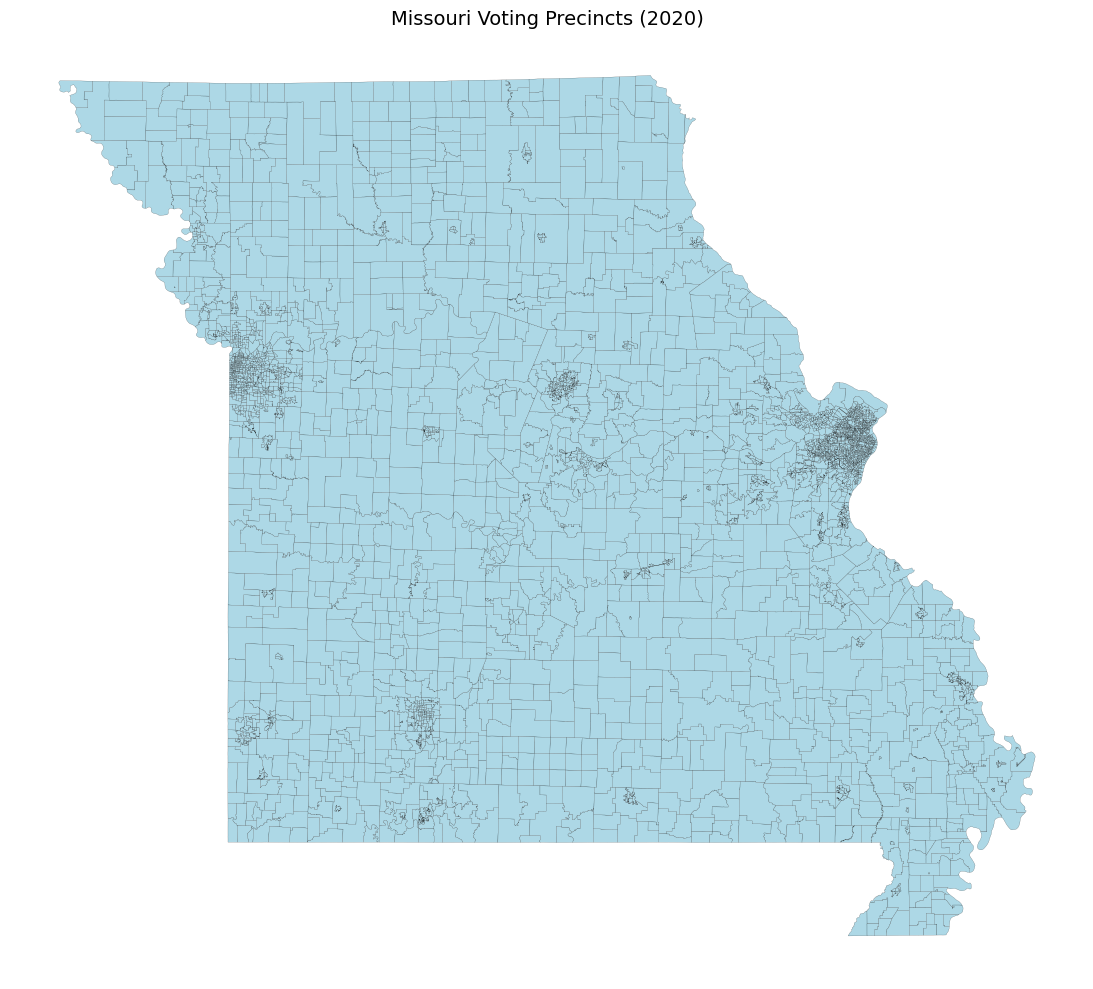

In [38]:
# Quick Visualization - Missouri Precincts Map

fig, ax = plt.subplots(figsize=(12, 10))
precincts_gdf.plot(ax=ax, edgecolor='black', linewidth=0.1, color='lightblue')
ax.set_title('Missouri Voting Precincts (2020)', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


---
# SECTION 3: Data Cleaning - Election Data
---

Clean and standardize election results across all three years:
1. Add year column
2. Drop precinct_code (2020/2024 only)
3. Normalize precinct and county names
4. Filter to Presidential results only
5. Combine into single dataset

In [39]:
# Define Precinct Name Normalization Function

def normalize_precinct_name(name):
    """
    Standardize precinct names for consistent joining across datasets.
    Missouri precinct names vary (e.g., 'Ward 1', 'WARD 1', 'Ward #1').
    """
    return (
        str(name)
        .upper()
        .replace('#', '')
        .replace('  ', ' ')
        .strip()
    )

print("normalize_precinct_name() function defined")

normalize_precinct_name() function defined


In [40]:
# Clean and Filter Election Results (Presidential Only)

election_2016_clean = (
    raw_election_2016
    .query("office == 'President'")
    .assign(year=2016)
    .assign(precinct_clean=lambda x: x['precinct'].apply(normalize_precinct_name))
    .assign(county_clean=lambda x: x['county'].str.upper().str.strip())
    [['year', 'county', 'county_clean', 'precinct', 'precinct_clean', 
      'office', 'district', 'candidate', 'party', 'votes']]
    .reset_index(drop=True)
)

election_2020_clean = (
    raw_election_2020
    .query("office == 'President'")
    .drop(columns=['precinct_code'], errors='ignore')
    .assign(year=2020)
    .assign(precinct_clean=lambda x: x['precinct'].apply(normalize_precinct_name))
    .assign(county_clean=lambda x: x['county'].str.upper().str.strip())
    [['year', 'county', 'county_clean', 'precinct', 'precinct_clean', 
      'office', 'district', 'candidate', 'party', 'votes']]
    .reset_index(drop=True)
)

election_2024_clean = (
    raw_election_2024
    .loc[lambda x: x['office'] == 'President']
    .drop(columns=['precinct_code'], errors='ignore')
    .assign(year=2024)
    .assign(precinct_clean=lambda x: x['precinct'].apply(normalize_precinct_name))
    .assign(county_clean=lambda x: x['county'].str.upper().str.strip())
    [['year', 'county', 'county_clean', 'precinct', 'precinct_clean', 
      'office', 'district', 'candidate', 'party', 'votes']]
    .reset_index(drop=True)
)

print("=" * 70)
print("PRESIDENTIAL ELECTION DATA CLEANED")
print("=" * 70)
print(f"2016 Presidential: {election_2016_clean.shape[0]:>8,} rows")
print(f"2020 Presidential: {election_2020_clean.shape[0]:>8,} rows")
print(f"2024 Presidential: {election_2024_clean.shape[0]:>8,} rows")
print("=" * 70)

PRESIDENTIAL ELECTION DATA CLEANED
2016 Presidential:   15,880 rows
2020 Presidential:   25,689 rows
2024 Presidential:   28,180 rows


In [41]:
# Combine All Election Years into Single Dataset

all_elections_df = pd.concat(
    [election_2016_clean, election_2020_clean, election_2024_clean], 
    ignore_index=True
)

print("=" * 70)
print("COMBINED ELECTION DATASET")
print("=" * 70)
print(f"Total Rows:    {all_elections_df.shape[0]:,}")
print(f"Total Columns: {all_elections_df.shape[1]}")
print(f"Years:         {sorted(all_elections_df['year'].unique().tolist())}")
print(f"Counties:      {all_elections_df['county_clean'].nunique()}")
print(f"Parties:       {all_elections_df['party'].unique().tolist()}")
print("=" * 70)
all_elections_df.head(10)

COMBINED ELECTION DATASET
Total Rows:    69,749
Total Columns: 10
Years:         [2016, 2020, 2024]
Counties:      117
Parties:       ['DEM', 'REP', 'LBT', 'CON', 'GTN', 'WRITE-IN', 'LIB', 'GRE', 'CST', 'WI', nan, 'GRN']


,year,county,county_clean,precinct,precinct_clean,office,district,candidate,party,votes
0,2016,Adair,ADAIR,SOUTHWEST ONE/BENTON,SOUTHWEST ONE/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,224.0
1,2016,Adair,ADAIR,SOUTHEAST TWO/BENTON,SOUTHEAST TWO/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,458.0
2,2016,Adair,ADAIR,SOUTHEAST THREE/BENTON,SOUTHEAST THREE/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,391.0
3,2016,Adair,ADAIR,NORTHEAST FOUR/BENTON,NORTHEAST FOUR/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,386.0
4,2016,Adair,ADAIR,NORTHEAST FIVE/BENTON,NORTHEAST FIVE/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,256.0
5,2016,Adair,ADAIR,NORTHEAST SIX/BENTON,NORTHEAST SIX/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,317.0
6,2016,Adair,ADAIR,TSU/BENTON,TSU/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,281.0
7,2016,Adair,ADAIR,RURAL BENTON/BENTON,RURAL BENTON/BENTON,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,359.0
8,2016,Adair,ADAIR,NOVINGER,NOVINGER,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,179.0
9,2016,Adair,ADAIR,BRASHEAR,BRASHEAR,President,NaN,"Hillary Rodham Clinton, Timothy Michael Kaine",DEM,143.0


---
# SECTION 4: Data Cleaning - Census Data
---

Clean census data for all three years. Each census year is processed identically:
1. Remove header artifact row (GEO_ID = "Geography")
2. Remove state-level totals
3. Extract county FIPS and clean county name
4. Add census year column
5. Rename ACS codes to readable names
6. Convert to numeric types
7. Calculate derived metrics (percentages)

In [42]:
# Define Census Cleaning Functions

# NOTE: We do NOT remove " city" from county names to preserve the distinction
# between St. Louis County (FIPS 29189) and St. Louis city (FIPS 29510)

def clean_census_income(df, census_year):
    """Clean census income data for a given year."""
    return (
        df
        .query("GEO_ID != 'Geography'")
        .query("GEO_ID.str.contains('0500000US', na=False)")
        .assign(census_year=census_year)
        .assign(county_fips=lambda x: x['GEO_ID'].str[-5:])
        .assign(county_name=lambda x: x['NAME'].str.replace(', Missouri', '').str.replace(' County', ''))
        .assign(county_clean=lambda x: x['county_name'].str.upper().str.strip())
        .rename(columns={'B19013_001E': 'median_household_income'})
        .assign(median_household_income=lambda x: pd.to_numeric(x['median_household_income'], errors='coerce'))
        [['census_year', 'county_fips', 'county_name', 'county_clean', 'median_household_income']]
        .reset_index(drop=True)
    )

def clean_census_education(df, census_year):
    """Clean census education data for a given year."""
    result = (
        df
        .query("GEO_ID != 'Geography'")
        .query("GEO_ID.str.contains('0500000US', na=False)")
        .assign(census_year=census_year)
        .assign(county_fips=lambda x: x['GEO_ID'].str[-5:])
        .assign(county_name=lambda x: x['NAME'].str.replace(', Missouri', '').str.replace(' County', ''))
        .assign(county_clean=lambda x: x['county_name'].str.upper().str.strip())
        .rename(columns={
            'B15003_001E': 'total_pop_25_plus',
            'B15003_017E': 'hs_diploma',
            'B15003_022E': 'bachelors_degree',
            'B15003_023E': 'masters_degree',
            'B15003_024E': 'professional_degree',
            'B15003_025E': 'doctorate_degree'
        })
        .reset_index(drop=True)
    )
    
    for col in ['total_pop_25_plus', 'hs_diploma', 'bachelors_degree', 'masters_degree', 'professional_degree', 'doctorate_degree']:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors='coerce')
    
    result['pct_bachelors_plus'] = (
        (result['bachelors_degree'] + result['masters_degree'] + 
         result['professional_degree'] + result['doctorate_degree']) 
        / result['total_pop_25_plus'] * 100
    ).round(2)
    
    return result[['census_year', 'county_fips', 'county_name', 'county_clean', 
                   'total_pop_25_plus', 'pct_bachelors_plus']]

def clean_census_race(df, census_year):
    """Clean census race data for a given year."""
    result = (
        df
        .query("GEO_ID != 'Geography'")
        .query("GEO_ID.str.contains('0500000US', na=False)")
        .assign(census_year=census_year)
        .assign(county_fips=lambda x: x['GEO_ID'].str[-5:])
        .assign(county_name=lambda x: x['NAME'].str.replace(', Missouri', '').str.replace(' County', ''))
        .assign(county_clean=lambda x: x['county_name'].str.upper().str.strip())
        .rename(columns={
            'B02001_001E': 'total_population',
            'B02001_002E': 'white_alone',
            'B02001_003E': 'black_alone'
        })
        .reset_index(drop=True)
    )
    
    for col in ['total_population', 'white_alone', 'black_alone']:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors='coerce')
    
    result['pct_white'] = (result['white_alone'] / result['total_population'] * 100).round(2)
    result['pct_minority'] = ((result['total_population'] - result['white_alone']) / result['total_population'] * 100).round(2)
    
    return result[['census_year', 'county_fips', 'county_name', 'county_clean', 
                   'total_population', 'pct_white', 'pct_minority']]

def clean_census_commute(df, census_year):
    """Clean census commute data for a given year."""
    result = (
        df
        .query("GEO_ID != 'Geography'")
        .query("GEO_ID.str.contains('0500000US', na=False)")
        .assign(census_year=census_year)
        .assign(county_fips=lambda x: x['GEO_ID'].str[-5:])
        .assign(county_name=lambda x: x['NAME'].str.replace(', Missouri', '').str.replace(' County', ''))
        .assign(county_clean=lambda x: x['county_name'].str.upper().str.strip())
        .rename(columns={
            'B08301_001E': 'total_workers',
            'B08301_003E': 'drove_alone',
            'B08301_010E': 'public_transit',
            'B08301_019E': 'walked'
        })
        .reset_index(drop=True)
    )
    
    for col in ['total_workers', 'drove_alone', 'public_transit', 'walked']:
        if col in result.columns:
            result[col] = pd.to_numeric(result[col], errors='coerce')
    
    result['pct_no_vehicle'] = ((result['public_transit'] + result['walked']) / result['total_workers'] * 100).round(2)
    
    return result[['census_year', 'county_fips', 'county_name', 'county_clean', 
                   'total_workers', 'pct_no_vehicle']]

def clean_census_sex_age(df, census_year):
    """Clean census sex by age data for a given year."""
    result = (
        df
        .query("GEO_ID != 'Geography'")
        .query("GEO_ID.str.contains('0500000US', na=False)")
        .assign(census_year=census_year)
        .assign(county_fips=lambda x: x['GEO_ID'].str[-5:])
        .assign(county_name=lambda x: x['NAME'].str.replace(', Missouri', '').str.replace(' County', ''))
        .assign(county_clean=lambda x: x['county_name'].str.upper().str.strip())
        .reset_index(drop=True)
    )
    
    for col in result.columns:
        if col.startswith('B01001'):
            result[col] = pd.to_numeric(result[col], errors='coerce')
    
    result['total_population'] = result['B01001_001E']
    
    male_18plus_cols = [f'B01001_{str(i).zfill(3)}E' for i in range(7, 26)]
    female_18plus_cols = [f'B01001_{str(i).zfill(3)}E' for i in range(31, 50)]
    
    male_18plus_cols = [c for c in male_18plus_cols if c in result.columns]
    female_18plus_cols = [c for c in female_18plus_cols if c in result.columns]
    
    result['voting_age_population'] = result[male_18plus_cols].sum(axis=1) + result[female_18plus_cols].sum(axis=1)
    result['pct_voting_age'] = (result['voting_age_population'] / result['total_population'] * 100).round(2)
    
    return result[['census_year', 'county_fips', 'county_name', 'county_clean', 
                   'total_population', 'voting_age_population', 'pct_voting_age']]

print("Census cleaning functions defined")

Census cleaning functions defined


In [43]:
# Clean Census Income Data (All Years)

census_income_2016 = clean_census_income(raw_census_2016_income, 2016)
census_income_2020 = clean_census_income(raw_census_2020_income, 2020)
census_income_2024 = clean_census_income(raw_census_2024_income, 2024)

all_census_income_df = pd.concat(
    [census_income_2016, census_income_2020, census_income_2024],
    ignore_index=True
)

print(f"Census Income cleaned: {all_census_income_df.shape[0]} rows ({all_census_income_df['census_year'].nunique()} years)")
all_census_income_df.head()

Census Income cleaned: 345 rows (3 years)


,census_year,county_fips,county_name,county_clean,median_household_income
0,2016,29001,Adair,ADAIR,37967
1,2016,29003,Andrew,ANDREW,54804
2,2016,29005,Atchison,ATCHISON,43438
3,2016,29007,Audrain,AUDRAIN,41930
4,2016,29009,Barry,BARRY,37869


In [44]:
# Clean Census Education Data (All Years)

census_education_2016 = clean_census_education(raw_census_2016_education, 2016)
census_education_2020 = clean_census_education(raw_census_2020_education, 2020)
census_education_2024 = clean_census_education(raw_census_2024_education, 2024)

all_census_education_df = pd.concat(
    [census_education_2016, census_education_2020, census_education_2024],
    ignore_index=True
)

print(f"Census Education cleaned: {all_census_education_df.shape[0]} rows ({all_census_education_df['census_year'].nunique()} years)")
all_census_education_df.head()

Census Education cleaned: 345 rows (3 years)


,census_year,county_fips,county_name,county_clean,total_pop_25_plus,pct_bachelors_plus
0,2016,29001,Adair,ADAIR,13621,30.49
1,2016,29003,Andrew,ANDREW,12005,23.98
2,2016,29005,Atchison,ATCHISON,3945,22.33
3,2016,29007,Audrain,AUDRAIN,17659,12.59
4,2016,29009,Barry,BARRY,24688,12.81


In [45]:
# Clean Census Race Data (All Years)

census_race_2016 = clean_census_race(raw_census_2016_race, 2016)
census_race_2020 = clean_census_race(raw_census_2020_race, 2020)
census_race_2024 = clean_census_race(raw_census_2024_race, 2024)

all_census_race_df = pd.concat(
    [census_race_2016, census_race_2020, census_race_2024],
    ignore_index=True
)

print(f"Census Race cleaned: {all_census_race_df.shape[0]} rows ({all_census_race_df['census_year'].nunique()} years)")
all_census_race_df.head()

Census Race cleaned: 345 rows (3 years)


,census_year,county_fips,county_name,county_clean,total_population,pct_white,pct_minority
0,2016,29001,Adair,ADAIR,25547,92.57,7.43
1,2016,29003,Andrew,ANDREW,17347,96.22,3.78
2,2016,29005,Atchison,ATCHISON,5380,97.83,2.17
3,2016,29007,Audrain,AUDRAIN,25868,89.10,10.90
4,2016,29009,Barry,BARRY,35716,92.96,7.04


In [46]:
# Clean Census Commute Data (All Years)

census_commute_2016 = clean_census_commute(raw_census_2016_commute, 2016)
census_commute_2020 = clean_census_commute(raw_census_2020_commute, 2020)
census_commute_2024 = clean_census_commute(raw_census_2024_commute, 2024)

all_census_commute_df = pd.concat(
    [census_commute_2016, census_commute_2020, census_commute_2024],
    ignore_index=True
)

print(f"Census Commute cleaned: {all_census_commute_df.shape[0]} rows ({all_census_commute_df['census_year'].nunique()} years)")
all_census_commute_df.head()

Census Commute cleaned: 345 rows (3 years)


,census_year,county_fips,county_name,county_clean,total_workers,pct_no_vehicle
0,2016,29001,Adair,ADAIR,10849,4.53
1,2016,29003,Andrew,ANDREW,8397,1.14
2,2016,29005,Atchison,ATCHISON,2597,3.43
3,2016,29007,Audrain,AUDRAIN,10584,3.69
4,2016,29009,Barry,BARRY,13885,2.53


In [47]:
# Clean Census Sex by Age Data (All Years)

census_sex_age_2016 = clean_census_sex_age(raw_census_2016_sex_age, 2016)
census_sex_age_2020 = clean_census_sex_age(raw_census_2020_sex_age, 2020)
census_sex_age_2024 = clean_census_sex_age(raw_census_2024_sex_age, 2024)

all_census_sex_age_df = pd.concat(
    [census_sex_age_2016, census_sex_age_2020, census_sex_age_2024],
    ignore_index=True
)

print(f"Census Sex/Age cleaned: {all_census_sex_age_df.shape[0]} rows ({all_census_sex_age_df['census_year'].nunique()} years)")
all_census_sex_age_df.head()

Census Sex/Age cleaned: 345 rows (3 years)


,census_year,county_fips,county_name,county_clean,total_population,voting_age_population,pct_voting_age
0,2016,29001,Adair,ADAIR,25547,20817,81.49
1,2016,29003,Andrew,ANDREW,17347,13355,76.99
2,2016,29005,Atchison,ATCHISON,5380,4339,80.65
3,2016,29007,Audrain,AUDRAIN,25868,19855,76.76
4,2016,29009,Barry,BARRY,35716,27535,77.09


---
# SECTION 5: Data Cleaning - Polling Locations & Shapefile
---

Clean polling locations and prepare shapefile for potential geospatial analysis.

In [48]:
# Clean Polling Locations Data

polling_locations_df = (
    raw_polling_locations
    .copy()
    .assign(county_clean=lambda x: x['county_name'].str.strip().str.upper())
    .assign(precinct_clean=lambda x: x['precinct_name'].apply(normalize_precinct_name))
    .assign(polling_address=lambda x: x['address'].str.strip())
)

print("=" * 70)
print("POLLING LOCATIONS CLEANED")
print("=" * 70)
print(f"Total Rows:           {polling_locations_df.shape[0]:,}")
print(f"Unique Counties:      {polling_locations_df['county_clean'].nunique()}")
print(f"Unique Precincts:     {polling_locations_df['precinct_clean'].nunique()}")
print(f"Unique Polling Places: {polling_locations_df['polling_place_id'].nunique()}")
print("=" * 70)
polling_locations_df.head()

POLLING LOCATIONS CLEANED
Total Rows:           14,354
Unique Counties:      116
Unique Precincts:     13913
Unique Polling Places: 2133


,election_date,state,county_name,jurisdiction,jurisdiction_type,precinct_id,precinct_name,polling_place_id,location_type,name,address,notes,source,source_date,source_notes,county_clean,precinct_clean,polling_address
0,2020-11-03,MO,Adair,Adair,county,1009-03,BRASHEAR/WILSON 03,BRASHEAR1,NaN,NEMO FAIR GROUNDS,"2700 E ILLINOIS ST KIRKSVILLE, 63501",NaN,website,2020-10-06,NaN,ADAIR,BRASHEAR/WILSON 03,"2700 E ILLINOIS ST KIRKSVILLE, 63501"
1,2020-11-03,MO,Adair,Adair,county,1009-04,BRASHEAR/WILSON 04,BRASHEAR1,NaN,NEMO FAIR GROUNDS,"2700 E ILLINOIS ST KIRKSVILLE, 63501",NaN,website,2020-10-06,NaN,ADAIR,BRASHEAR/WILSON 04,"2700 E ILLINOIS ST KIRKSVILLE, 63501"
2,2020-11-03,MO,Adair,Adair,county,1009-05,BRASHEAR/WILSON 05,BRASHEAR1,NaN,NEMO FAIR GROUNDS,"2700 E ILLINOIS ST KIRKSVILLE, 63501",NaN,website,2020-10-06,NaN,ADAIR,BRASHEAR/WILSON 05,"2700 E ILLINOIS ST KIRKSVILLE, 63501"
3,2020-11-03,MO,Adair,Adair,county,1009-07,BRASHEAR/WILSON 07,BRASHEAR1,NaN,NEMO FAIR GROUNDS,"2700 E ILLINOIS ST KIRKSVILLE, 63501",NaN,website,2020-10-06,NaN,ADAIR,BRASHEAR/WILSON 07,"2700 E ILLINOIS ST KIRKSVILLE, 63501"
4,2020-11-03,MO,Adair,Adair,county,1009-08,BRASHEAR/WILSON 08,BRASHEAR1,NaN,NEMO FAIR GROUNDS,"2700 E ILLINOIS ST KIRKSVILLE, 63501",NaN,website,2020-10-06,NaN,ADAIR,BRASHEAR/WILSON 08,"2700 E ILLINOIS ST KIRKSVILLE, 63501"


---
# SECTION 9: Exploratory Data Analysis (EDA)
---

Analyze patterns in:
- Statewide turnout trends
- County-level turnout variations
- Demographic correlations
- Polling resource distribution

---
# SECTION 6: Data Integration
---

Combine cleaned DataFrames into integrated analysis tables using pandas.


In [49]:
# Combine All Census Data

all_census_income_df = pd.concat([census_income_2016, census_income_2020, census_income_2024], ignore_index=True)
all_census_education_df = pd.concat([census_education_2016, census_education_2020, census_education_2024], ignore_index=True)
all_census_race_df = pd.concat([census_race_2016, census_race_2020, census_race_2024], ignore_index=True)
all_census_commute_df = pd.concat([census_commute_2016, census_commute_2020, census_commute_2024], ignore_index=True)
all_census_sex_age_df = pd.concat([census_sex_age_2016, census_sex_age_2020, census_sex_age_2024], ignore_index=True)

print('=' * 70)
print('CENSUS DATA COMBINED')
print('=' * 70)
print(f'Income:    {len(all_census_income_df):,} rows')
print(f'Education: {len(all_census_education_df):,} rows')
print(f'Race:      {len(all_census_race_df):,} rows')
print(f'Commute:   {len(all_census_commute_df):,} rows')
print(f'Sex/Age:   {len(all_census_sex_age_df):,} rows')
print('=' * 70)


CENSUS DATA COMBINED
Income:    345 rows
Education: 345 rows
Race:      345 rows
Commute:   345 rows
Sex/Age:   345 rows


---
# SECTION 7: Pandas Aggregations & Merges
---

Create analytical DataFrames using pandas operations (equivalent to SQL aggregations).


In [50]:
# Create Precinct Turnout DataFrame

precinct_turnout_df = (
    all_elections_df
    .groupby(['year', 'county_clean', 'precinct_clean'])
    .agg(
        total_votes=('votes', 'sum'),
        rep_votes=('votes', lambda x: x[all_elections_df.loc[x.index, 'party'] == 'REP'].sum()),
        dem_votes=('votes', lambda x: x[all_elections_df.loc[x.index, 'party'] == 'DEM'].sum())
    )
    .reset_index()
)

print(f'PRECINCT_TURNOUT: {len(precinct_turnout_df):,} rows')
precinct_turnout_df.head()


PRECINCT_TURNOUT: 10,318 rows


,year,county_clean,precinct_clean,total_votes,rep_votes,dem_votes
0,2016,ADAIR,ABSENTEE,1372.0,816.0,501.0
1,2016,ADAIR,BRASHEAR,825.0,638.0,143.0
2,2016,ADAIR,FEDERAL,8.0,3.0,5.0
3,2016,ADAIR,NORTHEAST FIVE/BENTON,745.0,435.0,256.0
4,2016,ADAIR,NORTHEAST FOUR/BENTON,872.0,400.0,386.0


In [51]:
# Create County Turnout DataFrame

county_turnout_df = (
    all_elections_df
    .groupby(['year', 'county_clean'])
    .agg(
        total_votes=('votes', 'sum'),
        precincts=('precinct_clean', 'nunique')
    )
    .reset_index()
)

# Add party percentages
party_votes = (
    all_elections_df
    .groupby(['year', 'county_clean', 'party'])['votes']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

county_turnout_df = county_turnout_df.merge(party_votes, on=['year', 'county_clean'])

if 'REP' in county_turnout_df.columns:
    county_turnout_df['rep_pct'] = (county_turnout_df['REP'] / county_turnout_df['total_votes'] * 100).round(2)
if 'DEM' in county_turnout_df.columns:
    county_turnout_df['dem_pct'] = (county_turnout_df['DEM'] / county_turnout_df['total_votes'] * 100).round(2)

print(f'COUNTY_TURNOUT: {len(county_turnout_df):,} rows')
county_turnout_df.head()


COUNTY_TURNOUT: 348 rows


,year,county_clean,total_votes,precincts,CON,CST,DEM,GRE,GRN,GTN,LBT,LIB,REP,WI,WRITE-IN,rep_pct,dem_pct
0,2016,ADAIR,10226.0,12,50.0,0.0,3500.0,0.0,0.0,147.0,426.0,0.0,6030.0,0.0,73.0,58.97,34.23
1,2016,ANDREW,9140.0,12,30.0,0.0,2045.0,0.0,0.0,64.0,336.0,0.0,6665.0,0.0,0.0,72.92,22.37
2,2016,ATCHISON,2730.0,6,5.0,0.0,541.0,0.0,0.0,14.0,104.0,0.0,2060.0,0.0,6.0,75.46,19.82
3,2016,AUDRAIN,10061.0,17,59.0,0.0,2570.0,0.0,0.0,73.0,363.0,0.0,6981.0,0.0,15.0,69.39,25.54
4,2016,BARRY,14605.0,17,63.0,0.0,2710.0,0.0,0.0,66.0,338.0,0.0,11428.0,0.0,0.0,78.25,18.56


In [52]:
# Create County Turnout Trend (pivoted by year)

county_turnout_trend_df = (
    county_turnout_df
    .pivot_table(
        index='county_clean',
        columns='year',
        values=['total_votes', 'rep_pct', 'dem_pct'],
        aggfunc='first'
    )
)

# Flatten column names
county_turnout_trend_df.columns = [f'{col[0]}_{col[1]}' for col in county_turnout_trend_df.columns]
county_turnout_trend_df = county_turnout_trend_df.reset_index()
county_turnout_trend_df = county_turnout_trend_df.rename(columns={'county_clean': 'COUNTY'})

print(f'COUNTY_TURNOUT_TREND: {len(county_turnout_trend_df):,} rows')
county_turnout_trend_df.head()


COUNTY_TURNOUT_TREND: 117 rows


,COUNTY,dem_pct_2016,dem_pct_2020,dem_pct_2024,rep_pct_2016,rep_pct_2020,rep_pct_2024,total_votes_2016,total_votes_2020,total_votes_2024
0,ADAIR,34.23,35.89,32.56,58.97,62.05,66.13,10226.0,10336.0,10239.0
1,ANDREW,22.37,24.11,23.48,72.92,74.39,75.22,9140.0,9752.0,9847.0
2,ATCHISON,19.82,20.04,19.50,75.46,78.14,79.32,2730.0,2814.0,2713.0
3,AUDRAIN,25.54,25.38,25.54,69.39,72.56,73.16,10061.0,10656.0,10523.0
4,BARRY,18.56,18.90,17.77,78.25,79.66,81.27,14605.0,15598.0,16165.0


In [53]:
# Create County Census DataFrame (pivoted by year)

# Select only the key columns from each census table before merging
income_cols = all_census_income_df[['county_clean', 'census_year', 'median_household_income']].copy()
education_cols = all_census_education_df[['county_clean', 'census_year', 'pct_bachelors_plus']].copy()
race_cols = all_census_race_df[['county_clean', 'census_year', 'total_population', 'pct_minority']].copy()
commute_cols = all_census_commute_df[['county_clean', 'census_year', 'pct_no_vehicle']].copy()
sex_age_cols = all_census_sex_age_df[['county_clean', 'census_year', 'voting_age_population']].copy()

# Merge on county and year
census_merged = (
    income_cols
    .merge(education_cols, on=['county_clean', 'census_year'], how='outer')
    .merge(race_cols, on=['county_clean', 'census_year'], how='outer')
    .merge(commute_cols, on=['county_clean', 'census_year'], how='outer')
    .merge(sex_age_cols, on=['county_clean', 'census_year'], how='outer')
)

print(f'COUNTY_CENSUS (merged): {len(census_merged):,} rows')
census_merged.head()

COUNTY_CENSUS (merged): 345 rows


,county_clean,census_year,median_household_income,pct_bachelors_plus,total_population,pct_minority,pct_no_vehicle,voting_age_population
0,ADAIR,2016,37967,30.49,25547,7.43,4.53,20817
1,ADAIR,2020,42301,31.22,25468,9.28,4.50,20700
2,ADAIR,2024,61536,35.53,25301,11.62,3.06,20561
3,ANDREW,2016,54804,23.98,17347,3.78,1.14,13355
4,ANDREW,2020,58911,26.56,17554,4.93,2.00,13520


In [54]:
# Create County Polling Summary

county_polling_summary_df = (
    polling_locations_df
    .groupby('county_clean')
    .agg(
        unique_polling_places=('polling_place_id', 'nunique'),
        unique_precincts=('precinct_clean', 'nunique'),
        total_records=('polling_place_id', 'count')
    )
    .reset_index()
)

county_polling_summary_df['precincts_per_polling_place'] = (
    county_polling_summary_df['unique_precincts'] / 
    county_polling_summary_df['unique_polling_places']
).round(2)

print(f'COUNTY_POLLING_SUMMARY: {len(county_polling_summary_df):,} rows')
county_polling_summary_df.head()


COUNTY_POLLING_SUMMARY: 116 rows


,county_clean,unique_polling_places,unique_precincts,total_records,precincts_per_polling_place
0,ADAIR,10,49,49,4.90
1,ANDREW,19,80,80,4.21
2,ATCHISON,5,55,55,11.00
3,AUDRAIN,15,127,127,8.47
4,BARRY,16,169,169,10.56


---
# SECTION 8: Data Quality Validation
---

Verify data integrity and row counts.


In [55]:
# Data Quality Summary

print('=' * 70)
print('DATA QUALITY SUMMARY')
print('=' * 70)

print('\nRAW DATA:')
print(f'  Elections 2016:    {len(raw_election_2016):,} rows')
print(f'  Elections 2020:    {len(raw_election_2020):,} rows')
print(f'  Elections 2024:    {len(raw_election_2024):,} rows')
print(f'  Polling Locations: {len(raw_polling_locations):,} rows')
print(f'  Precincts (geo):   {len(precincts_gdf):,} rows')

print('\nCLEANED DATA:')
print(f'  All Elections:     {len(all_elections_df):,} rows')
print(f'  Polling Locations: {len(polling_locations_df):,} rows')

print('\nAGGREGATED DATA:')
print(f'  Precinct Turnout:  {len(precinct_turnout_df):,} rows')
print(f'  County Turnout:    {len(county_turnout_df):,} rows')
print(f'  County Trend:      {len(county_turnout_trend_df):,} rows')
print(f'  County Polling:    {len(county_polling_summary_df):,} rows')

print('=' * 70)


DATA QUALITY SUMMARY

RAW DATA:
  Elections 2016:    128,859 rows
  Elections 2020:    132,123 rows
  Elections 2024:    190,270 rows
  Polling Locations: 14,354 rows
  Precincts (geo):   4,604 rows

CLEANED DATA:
  All Elections:     69,749 rows
  Polling Locations: 14,354 rows

AGGREGATED DATA:
  Precinct Turnout:  10,318 rows
  County Turnout:    348 rows
  County Trend:      117 rows
  County Polling:    116 rows


---
# SECTION 9: Exploratory Data Analysis
---

Analyze patterns in turnout, demographics, and polling resources.


In [56]:
# Statewide Turnout Summary by Year

statewide = (
    county_turnout_df
    .groupby('year')
    .agg(
        total_votes=('total_votes', 'sum'),
        counties=('county_clean', 'nunique')
    )
    .reset_index()
)

print('=' * 70)
print('STATEWIDE TURNOUT BY YEAR')
print('=' * 70)
print(statewide.to_string(index=False))
print('=' * 70)


STATEWIDE TURNOUT BY YEAR
 year  total_votes  counties
 2016    2808298.0       116
 2020    2963270.0       116
 2024    2995327.0       116


In [57]:
# Top 10 Counties by Total Votes (2020)

top_2020 = (
    county_turnout_df
    .query('year == 2020')
    .nlargest(10, 'total_votes')
    [['county_clean', 'total_votes', 'rep_pct', 'dem_pct']]
)

print('=' * 70)
print('TOP 10 COUNTIES BY VOTES (2020)')
print('=' * 70)
print(top_2020.to_string(index=False))
print('=' * 70)


TOP 10 COUNTIES BY VOTES (2020)
    county_clean  total_votes  rep_pct  dem_pct
ST. LOUIS COUNTY     535998.0    37.18    61.22
     ST. CHARLES     222017.0    57.83    40.33
          GREENE     141800.0    58.98    38.83
     KANSAS CITY     136645.0    19.32    78.79
         JACKSON     136300.0    57.17    40.32
  ST. LOUIS CITY     133867.0    16.04    82.24
            CLAY     126569.0    51.04    46.93
       JEFFERSON     116688.0    66.03    32.16
           BOONE      91168.0    42.39    54.91
            CASS      57408.0    64.79    33.19


In [58]:
# Polling Resource Strain Analysis

# Merge 2020 votes with polling data
votes_2020 = county_turnout_df.query('year == 2020')[['county_clean', 'total_votes']]
strain_df = county_polling_summary_df.merge(votes_2020, on='county_clean', how='left')
strain_df['voters_per_polling_place'] = (strain_df['total_votes'] / strain_df['unique_polling_places']).round(0)

top_strain = strain_df.nlargest(10, 'voters_per_polling_place')[[
    'county_clean', 'total_votes', 'unique_polling_places', 'voters_per_polling_place'
]]

print('=' * 70)
print('TOP 10 COUNTIES - HIGHEST VOTERS PER POLLING PLACE (2020)')
print('=' * 70)
print(top_strain.to_string(index=False))
print('=' * 70)


TOP 10 COUNTIES - HIGHEST VOTERS PER POLLING PLACE (2020)
county_clean  total_votes  unique_polling_places  voters_per_polling_place
     JOHNSON      23123.0                     10                    2312.0
   JEFFERSON     116688.0                     53                    2202.0
      PLATTE      57270.0                     27                    2121.0
     MADISON       5676.0                      3                    1892.0
   CHRISTIAN      46839.0                     25                    1874.0
      GREENE     141800.0                     76                    1866.0
 ST. CHARLES     222017.0                    122                    1820.0
     CLINTON      10888.0                      6                    1815.0
     PULASKI      14414.0                      8                    1802.0
 KANSAS CITY     136645.0                     76                    1798.0


---
# SECTION 10: Geospatial Analysis
---

**Owner: David**

This section contains geospatial analysis using precinct boundary shapefiles.


In [59]:
# =============================================================================
# GEOSPATIAL ANALYSIS - DAVID
# =============================================================================

print('=' * 70)
print('GEOSPATIAL ANALYSIS - DAVID')
print('=' * 70)
print('Shapefile loaded: MO 2020 Precincts')
print(f'Total precincts: {precincts_gdf.shape[0]:,}')
print(f'CRS: {precincts_gdf.crs}')
print(f'Geometry types: {precincts_gdf.geom_type.unique().tolist()}')
print('=' * 70)

# View first few precincts
precincts_gdf[['NAME20', 'COUNTYFP20', 'ALAND20', 'INTPTLAT20', 'INTPTLON20']].head(10)


GEOSPATIAL ANALYSIS - DAVID
Shapefile loaded: MO 2020 Precincts
Total precincts: 4,604
CRS: EPSG:4269
Geometry types: ['Polygon', 'MultiPolygon']


,NAME20,COUNTYFP20,ALAND20,INTPTLAT20,INTPTLON20
0,Bolckow,003,62195606,+40.0959853,-094.8454455
1,Rosendale,003,66268191,+40.0380886,-094.8274513
2,Clay,003,117237497,+40.0917961,-094.9668992
3,Rochester,003,85917201,+39.9297442,-094.7416770
4,Empire East,003,66854677,+40.0034521,-094.6496043
5,Helena,003,73226913,+39.9287288,-094.6450161
6,Platte West,003,110451112,+40.0664235,-094.7364974
7,Fillmore,003,89775840,+40.0152529,-094.9331098
8,John Glenn,003,31411656,+39.8537865,-094.8472697
9,Beeler,003,48860965,+39.8745176,-094.7989400


In [60]:
# # =============================================================================
# # EXAMPLE: Choropleth by County (Land Area)
# # =============================================================================
# # This demonstrates how to create a choropleth map.
# # David can modify this to show turnout, polling strain, etc.

# # fig, ax = plt.subplots(figsize=(14, 10))

# # Color by land area (ALAND20)
# precincts_gdf.plot(
#     ax=ax,
#     column='ALAND20',
#     cmap='YlOrRd',
#     edgecolor='black',
#     linewidth=0.1,
#     legend=True,
#     legend_kwds={'label': 'Land Area (sq meters)', 'shrink': 0.6)
# )

# ax.set_title('Missouri Precincts by Land Area', fontsize=14)
# ax.set_axis_off()
# plt.tight_layout()
# plt.show()


---
# SECTION 11: Summary & Next Steps
---

## Data Pipeline Complete

### DataFrames Created:
- `all_elections_df` - Combined presidential results (all years)
- `polling_locations_df` - Cleaned polling locations
- `precincts_gdf` - GeoDataFrame with precinct boundaries
- `county_turnout_df` - County-level turnout by year
- `county_turnout_trend_df` - Turnout trends pivoted by year
- `county_polling_summary_df` - Polling resources by county

### Next Steps:
1. Build predictive models for voter turnout
2. Create prescriptive recommendations for resource allocation
3. Develop interactive visualizations
4. Complete geospatial analysis (David)


In [61]:
# Final Status

print('=' * 70)
print('NOTEBOOK EXECUTION COMPLETE')
print('=' * 70)
print(f'''
DATA LOADED:
  • 3 Election years (2016, 2020, 2024)
  • 5 Census tables per year (15 total)
  • Polling locations (2020)
  • Precinct shapefile (4,604 precincts)

ANALYSIS READY:
  • County-level turnout trends
  • Polling resource strain metrics
  • Geospatial visualization

NEXT STEPS:
  • Predictive modeling
  • Resource allocation recommendations
''')
print('=' * 70)


NOTEBOOK EXECUTION COMPLETE

DATA LOADED:
  • 3 Election years (2016, 2020, 2024)
  • 5 Census tables per year (15 total)
  • Polling locations (2020)
  • Precinct shapefile (4,604 precincts)

ANALYSIS READY:
  • County-level turnout trends
  • Polling resource strain metrics
  • Geospatial visualization

NEXT STEPS:
  • Predictive modeling
  • Resource allocation recommendations

